# Homework 3: Download and analyze any data using tools you learned in class

### IMPORTANT: Save your notebook and files (if you import locally) 
### IMPORTANT: See my example data folder: data/hw/hw_3/cory-baird
### **HW Requirements**

- **Relative Paths Only**
  - Use relative paths from the project root (e.g., `data/hw/hw_3/student-name/data.csv`).
  - Never hardcode absolute paths specific to your local machine (e.g., `/Users/username/...`).
- **File Size Limit**
  - Any committed dataset must be reasonable in size (strictly under 10 megabytes).
    - If you have to filter the dataset (to make it smaller) and upload a smaller version

- **Dataset Selection**
  - Select a policy-relevant dataset with at least 50 observations (e.g., 50 states, countries, or time periods) for meaningful analysis.
  - You can use example datasets from [here](../../../docs/example_datasets.md)

- **Data Acquisition**
  - You are highly encouraged to fetch data programmatically using an API (e.g. using `requests` with World Bank, US Census, or other public APIs) or load a direct public URL.

  - Alternatively, you may upload a local file, provided it is committed to your repository.
    - If you read csv/parquet etc use relative paths such as `data/hw/hw_3/student-name/data.csv`.
    - You can use example datasets from [here](../../../docs/example_datasets.md)

- **Reproducibility**
  - Commit both this notebook and the dataset so that your grader can run all cells from top to bottom out-of-the-box.

## IMPORTANT

---
### **Objectives**
- Select, acquire, and load a policy-relevant dataset of your choice.
- Apply clean code principles (environment checks, Python collections, standardized variable naming).
- Preprocess and standardize columns using Pandas techniques.
- Programmatically merge your primary dataset with a secondary source.
- Segment your data and run custom aggregations (using groupby or custom grouping strategies).
- Create customized visualizations and run exploratory regression analysis to discover policy insights.

### **Concept Reference Map**
- **Data Acquisition**: APIs (`requests` library), reading Parquet/CSV (Week 2/3 basics, Week 4 `1-visualization_basics.ipynb`)
- **Data Manipulation**: Selecting, renaming columns, filtering (`query()`), dropping NaNs (Week 4 `1-visualization_basics.ipynb`)
- **Aggregation**: Groupby, descriptive statistics (`describe()`, `mean()`) (Week 4 `1-visualization_basics.ipynb`)
- **Data Merging**: Pandas `merge()` matching indices or keys (Week 4 `2-merging_practice.ipynb`)
- **Visualization**: Scatter plots, line/bar charts, customization (Week 4 / Week 6 `1-regression.ipynb`)
- **Modeling**: Simple Linear Regression (`statsmodels`), line of best fit (Week 6 `1-regression.ipynb`)

---

### **Part 1: Data Acquisition & Environment Preparation**

- **Environment Setup**
  - Use python's `os` library (as reviewed in Week 3) to print your current working directory (`os.getcwd()`) and list the files in your project directory (`os.listdir()`) to ensure your paths are configured correctly.
- **Acquisition Steps**
  - Programmatically fetch data using `requests` or read directly from a public URL using Pandas.
  - If loading a committed local dataset, load it using a relative path.
- **Code Requirements**
  - Define variables using standardized, descriptive names.
  - Keep all function and method arguments on a single line.
  - Do not use docstrings (`""" """`) or runtime type checking in your helper methods.

In [31]:
import os
import pandas as pd
import requests
import matplotlib.pyplot as plt


# You can use example datasets here docs/example_datasets.md

# 1. Print environment details (working directory and local folder contents)
# If you read csv/parquet etc use relative paths such as data/hw/hw_3/student-name/data.csv
print(os.getcwd())
print(os.listdir())

# 2. Acquire and load your primary dataset
url_base = "https://api.worldbank.org/v2/"
indicator_gdp = "NY.GDP.PCAP.CD"
indicator_co2 = "EN.GHG.CO2.PC.CE.AR5"
date_start = 2000
date_end = 2025
data_folder = "../../../data/hw/hw_3/Martin-Hiraoka/"

c:\Users\marti\Desktop\datascience-publicpolicy-2026\notebooks\hw\hw_3
['hw_3.ipynb']


In [32]:
os.getcwd()

'c:\\Users\\marti\\Desktop\\datascience-publicpolicy-2026\\notebooks\\hw\\hw_3'

In [33]:
print("Fetching data from " + url_base)

Fetching data from https://api.worldbank.org/v2/


In [34]:
def download_worldbank_data(indicator, start_date, end_date):
    url = f"{url_base}country/all/indicator/{indicator}?date={start_date}:{end_date}&format=json&per_page=20000"
    response = requests.get(url)
    records = response.json()[1]
    df = pd.DataFrame(records)
    return df

In [35]:
df_gdp_raw = download_worldbank_data(indicator_gdp, date_start, date_end)
df_co2_raw = download_worldbank_data(indicator_co2, date_start, date_end)

df_co2_raw.to_csv(data_folder + "co2_emissions.csv", index=False)
df_gdp_raw.to_csv(data_folder + "gdp_percapita.csv", index=False)

print("GDP shape:", df_gdp_raw.shape)
print("CO2 shape:", df_co2_raw.shape)
print("Files saved:", os.listdir(data_folder))

GDP shape: (6916, 8)
CO2 shape: (6916, 8)
Files saved: ['co2_emissions.csv', 'gdp_percapita.csv']


### **Dataset Context & Relevance**

- **Dataset Source**
  - Specify the source of your dataset (e.g., API name, public organization, or website URL).

World Bank API

### **Part 2: Data Cleaning & Preprocessing**

- **Data Inspection**
  - Inspect column names, data types, and non-null counts using `.info()` and `.head()`.
- **Preprocessing Tasks**
  - Select a subset of columns necessary for your policy inquiry.
  - Standardize column names to a clean formatting (preferably `snake_case` or another consistent style).
  - Identify and handle missing values (`NaN`s) by dropping or filling them.
- **Python Grammar Tip**
  - You are encouraged to use a Python dictionary (as reviewed in Week 2 & 3) to map and rename your column names cleanly.

In [36]:
# 1. Inspect data structure using pandas methods
print(df_gdp_raw.columns)

Index(['indicator', 'country', 'countryiso3code', 'date', 'value', 'unit',
       'obs_status', 'decimal'],
      dtype='object')


In [37]:
df_gdp_raw.info()
df_gdp_raw.head(2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6916 entries, 0 to 6915
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   indicator        6916 non-null   object 
 1   country          6916 non-null   object 
 2   countryiso3code  6916 non-null   object 
 3   date             6916 non-null   object 
 4   value            6433 non-null   float64
 5   unit             6916 non-null   object 
 6   obs_status       6916 non-null   object 
 7   decimal          6916 non-null   int64  
dtypes: float64(1), int64(1), object(6)
memory usage: 432.4+ KB


,indicator,country,countryiso3code,date,value,unit,obs_status,decimal
0,"{'id': 'NY.GDP.PCAP.CD', 'value': 'GDP per cap...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2025,NaN,,,1
1,"{'id': 'NY.GDP.PCAP.CD', 'value': 'GDP per cap...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2024,1615.396356,,,1


In [38]:
print(df_co2_raw.columns)
print(df_co2_raw['indicator'][0])

Index(['indicator', 'country', 'countryiso3code', 'date', 'value', 'unit',
       'obs_status', 'decimal'],
      dtype='object')
{'id': 'EN.GHG.CO2.PC.CE.AR5', 'value': 'Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)'}


In [39]:
df_co2_raw.info()
df_co2_raw.head(2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6916 entries, 0 to 6915
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   indicator        6916 non-null   object 
 1   country          6916 non-null   object 
 2   countryiso3code  6916 non-null   object 
 3   date             6916 non-null   object 
 4   value            6275 non-null   float64
 5   unit             6916 non-null   object 
 6   obs_status       6916 non-null   object 
 7   decimal          6916 non-null   int64  
dtypes: float64(1), int64(1), object(6)
memory usage: 432.4+ KB


,indicator,country,countryiso3code,date,value,unit,obs_status,decimal
0,"{'id': 'EN.GHG.CO2.PC.CE.AR5', 'value': 'Carbo...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2025,NaN,,,1
1,"{'id': 'EN.GHG.CO2.PC.CE.AR5', 'value': 'Carbo...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2024,0.83768,,,1


In [40]:
df_co2_raw['country'] = df_co2_raw['country'].apply(lambda x: x['value'])
df_co2_raw['indicator'] = df_co2_raw['indicator'].apply(lambda x: x['value'])
df_gdp_raw['country'] = df_gdp_raw['country'].apply(lambda x: x['value'])
df_gdp_raw['indicator'] = df_gdp_raw['indicator'].apply(lambda x: x['value'])

rename_map_co2 = {'country': 'Country', 'countryiso3code': 'Country code', 'date': 'Year', 'value': 'CO2 emissions per capita'}
rename_map_gdp = {'country': 'Country', 'countryiso3code': 'Country code', 'date': 'Year', 'value': 'GDP per capita'}

df_co2_clean = df_co2_raw.rename(columns=rename_map_co2)
df_gdp_clean = df_gdp_raw.rename(columns=rename_map_gdp)

In [41]:
# 2. Rename columns and select a clean subset
df_gdp_clean = df_gdp_raw.rename(columns={'country': 'Country','countryiso3code': 'Country code','date': 'Year','value': 'GDP per capita'})
df_gdp_clean.head(2)

,indicator,Country,Country code,Year,GDP per capita,unit,obs_status,decimal
0,GDP per capita (current US$),Africa Eastern and Southern,AFE,2025,NaN,,,1
1,GDP per capita (current US$),Africa Eastern and Southern,AFE,2024,1615.396356,,,1


In [42]:
df_co2_clean = df_co2_raw.rename(columns={'country': 'Country','countryiso3code': 'Country code','date': 'Year','value': 'CO2 emissions per capita'})
df_co2_clean.head(2)

,indicator,Country,Country code,Year,CO2 emissions per capita,unit,obs_status,decimal
0,Carbon dioxide (CO2) emissions excluding LULUC...,Africa Eastern and Southern,AFE,2025,NaN,,,1
1,Carbon dioxide (CO2) emissions excluding LULUC...,Africa Eastern and Southern,AFE,2024,0.83768,,,1


In [43]:
# 4. Handle missing values (NaNs) if necessary
df_gdp_clean = df_gdp_clean.dropna().drop(columns=['indicator', 'unit', 'obs_status', 'decimal'])
df_gdp_clean.head(2)

,Country,Country code,Year,GDP per capita
1,Africa Eastern and Southern,AFE,2024,1615.396356
2,Africa Eastern and Southern,AFE,2023,1571.449189


In [44]:
df_co2_clean = df_co2_clean.dropna().drop(columns=['indicator', 'unit', 'obs_status', 'decimal'])
df_co2_clean.head(2)

,Country,Country code,Year,CO2 emissions per capita
1,Africa Eastern and Southern,AFE,2024,0.837680
2,Africa Eastern and Southern,AFE,2023,0.838104


### **Part 3: Merging Datasets**

- **Secondary Source Selection**
  - Programmatically download/read another related dataset.
- **Clean & Standardize**
  - Preprocess and rename the columns of the secondary dataset.
- **Merging Process**
  - Merge both datasets on a common key (such as country code or year).
  - Display the shape and head of your merged dataset to verify that the join was successful.

In [45]:
# 1. Load and clean the secondary dataset
# I ALREDY DID IN THE PREVIOUS STEPS

In [46]:
# 2. Merge your datasets on a common key
print(df_co2_clean['Year'].dtype)
print(df_gdp_clean['Year'].dtype)
df_co2_clean['Year'] = df_co2_clean['Year'].astype(int)
df_gdp_clean['Year'] = df_gdp_clean['Year'].astype(int)

object
object


In [47]:
df_merged = pd.merge(df_co2_clean, df_gdp_clean, on=['Country code', 'Year'])
df_merged.head(2)

,Country_x,Country code,Year,CO2 emissions per capita,Country_y,GDP per capita
0,Africa Eastern and Southern,AFE,2024,0.837680,Africa Eastern and Southern,1615.396356
1,Africa Eastern and Southern,AFE,2023,0.838104,Africa Eastern and Southern,1571.449189


### **Merge Verification**

- **Merge Key**
  - Describe the matching key you selected (e.g. country, state, year).
- **Observations Retained**
  - Specify how many matching rows were successfully kept after merging.

At first I merged on country code and year. After merging, I have repeated values for country. So i also merge on country. I also want to reorder the columns. 6,444 rows were retained

In [48]:
df_merged = df_merged.drop(columns=['Country_y'])
df_merged = df_merged.rename(columns={'Country_x': 'Country'})
df_merged.head(2)

,Country,Country code,Year,CO2 emissions per capita,GDP per capita
0,Africa Eastern and Southern,AFE,2024,0.837680,1615.396356
1,Africa Eastern and Southern,AFE,2023,0.838104,1571.449189


In [49]:
print(df_merged.shape)

(6444, 5)


In [50]:
df_merged['Country'].unique()

array(['Africa Eastern and Southern', 'Africa Western and Central',
       'Arab World', 'Caribbean small states',
       'Central Europe and the Baltics', 'Early-demographic dividend',
       'East Asia & Pacific',
       'East Asia & Pacific (excluding high income)',
       'East Asia & Pacific (IDA & IBRD countries)', 'Euro area',
       'Europe & Central Asia',
       'Europe & Central Asia (excluding high income)',
       'Europe & Central Asia (IDA & IBRD countries)', 'European Union',
       'Fragile and conflict affected situations',
       'Heavily indebted poor countries (HIPC)', 'High income',
       'IBRD only', 'IDA & IBRD total', 'IDA blend', 'IDA only',
       'IDA total', 'Late-demographic dividend',
       'Latin America & Caribbean',
       'Latin America & Caribbean (excluding high income)',
       'Latin America & the Caribbean (IDA & IBRD countries)',
       'Least developed countries: UN classification',
       'Low & middle income', 'Low income', 'Lower middle in

In [51]:
aggregates = ['AFE', 'AFW', 'ARB', 'CSS', 'CEB', 'EAR', 'EAS', 'EAP', 'TEA',
              'EMU', 'ECS', 'ECA', 'TEC', 'EUU', 'FCS', 'HPC', 'HIC', 'IBD',
              'IBT', 'IDB', 'IDX', 'IDA', 'LTE', 'LAC', 'TLA', 'LCN', 'LDC',
              'LMY', 'LIC', 'LMC', 'MEA', 'MNA', 'TMN', 'MIC', 'NAC', 'OED',
              'OSS', 'PSS', 'PST', 'PRE', 'SST', 'SAS', 'SAR', 'TSA', 'SSF',
              'SSA', 'TSS', 'UMC', 'WLD']

df_merged = df_merged[~df_merged['Country code'].isin(aggregates)]
print("Shape after filtering:", df_merged.shape)
print(df_merged['Country'].nunique(), "individual countries remaining")

aggregate_keywords = ['income', 'world', 'states', 'area', 'asia', 
                      'africa', 'europe', 'america', 'pacific', 'middle east',
                      'caribbean', 'dividend', 'OECD', 'IBRD', 'IDA', 
                      'fragile', 'indebted', 'classified', 'total', 'union',
                      'north', 'south', 'east', 'west', 'central', 'latin']

pattern = '|'.join(aggregate_keywords)
df_merged = df_merged[~df_merged['Country'].str.contains(pattern, case=False)]

print("Shape after filtering:", df_merged.shape)
print(df_merged['Country'].nunique(), "individual countries remaining")
print(df_merged['Country'].unique())


Shape after filtering: (5344, 5)
204 individual countries remaining
Shape after filtering: (4777, 5)
193 individual countries remaining
['Afghanistan' 'Albania' 'Algeria' 'Angola' 'Antigua and Barbuda'
 'Argentina' 'Armenia' 'Aruba' 'Australia' 'Austria' 'Azerbaijan'
 'Bahamas, The' 'Bahrain' 'Bangladesh' 'Barbados' 'Belarus' 'Belgium'
 'Belize' 'Benin' 'Bermuda' 'Bhutan' 'Bolivia' 'Bosnia and Herzegovina'
 'Botswana' 'Brazil' 'Brunei Darussalam' 'Bulgaria' 'Burkina Faso'
 'Burundi' 'Cabo Verde' 'Cambodia' 'Cameroon' 'Canada' 'Cayman Islands'
 'Chad' 'Chile' 'China' 'Colombia' 'Comoros' 'Congo, Dem. Rep.'
 'Congo, Rep.' 'Costa Rica' "Cote d'Ivoire" 'Croatia' 'Cuba' 'Cyprus'
 'Czechia' 'Denmark' 'Djibouti' 'Dominica' 'Dominican Republic' 'Ecuador'
 'Egypt, Arab Rep.' 'El Salvador' 'Equatorial Guinea' 'Eritrea' 'Estonia'
 'Eswatini' 'Ethiopia' 'Faroe Islands' 'Fiji' 'Finland' 'France'
 'French Polynesia' 'Gabon' 'Gambia, The' 'Georgia' 'Germany' 'Ghana'
 'Greece' 'Greenland' 'Grenada' 'G

Here I messed up and noticed that the world bank includes so many aggregates already as 'countries'. I asked the AI for help and gave me this list, to just keep individual countries. I guess it would have been easier to choose only the countries from the beginning, but i was scared to go so far up and start retouching things haha

### **Part 4: Aggregation & Groupby Analysis**

- **Aggregation Task**
  - Segment your indicators using `.groupby()` to calculate descriptive metrics (such as `.mean()`, `.median()`, `.min()`, or `.max()`) across different categories.
- **Backup Strategies (If your dataset does not have natural multiple groups)**
  - If your dataset consists of only continuous variables, choose one of these backup strategies:
    - **Binning**: Use `pd.cut()` to partition a continuous variable into groups (e.g. splitting GDP per capita into low, medium, and high income groups).
    - **Threshold Filtering**: Segment your dataset into two groups based on a threshold (e.g. countries with life expectancy > 75 vs. <= 75).
    - **Dictionary Mapping**: Create a custom Python dictionary (as reviewed in Week 2 & 3) mapping continuous features to custom categories, and map/merge it into your DataFrame to create groups.

In [52]:
gdp_bins = [0, 5000, 20000, 60000, float('inf')]
gdp_labels = ['Low', 'Lower-Middle', 'Upper-Middle', 'High']
df_merged['GDP Category'] = pd.cut(df_merged['GDP per capita'], bins=gdp_bins, labels=gdp_labels)
df_merged.head(2)

,Country,Country code,Year,CO2 emissions per capita,GDP per capita,GDP Category
1500,Afghanistan,AFG,2023,0.280995,413.757895,Low
1501,Afghanistan,AFG,2022,0.278421,357.261153,Low


In [53]:
df_merged_descriptive = df_merged.groupby('GDP Category')[['CO2 emissions per capita', 'GDP per capita']].describe()
df_merged_descriptive

C:\Users\marti\AppData\Local\Temp\ipykernel_36028\3560383390.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_merged_descriptive = df_merged.groupby('GDP Category')[['CO2 emissions per capita', 'GDP per capita']].describe()


CO2 emissions per capita                                  \
                                count       mean        std       min   
GDP Category                                                            
Low                            2415.0   1.341474   1.782810  0.000000   
Lower-Middle                   1192.0   6.793561  13.475542  0.000000   
Upper-Middle                    978.0   9.337768   7.306210  0.001209   
High                            192.0  11.515144  12.727775  0.038405   

                                                        GDP per capita  \
                   25%       50%        75%         max          count   
GDP Category                                                             
Low           0.249270  0.705637   1.681874   13.146173         2415.0   
Lower-Middle  2.166198  3.944970   7.094483  202.865184         1192.0   
Upper-Middle  4.587624  7.823224  11.100576   53.236385          978.0   
High          4.315153  7.180931  10.585920   53.599259          192.0   

                                                                      \
                      mean           std           min           25%   
GDP Category                                                           
Low            1907.079399   1359.280178    109.593814    758.386037   
Lower-Middle  10303.351569   4213.615278   5002.657987   6656.597405   
Upper-Middle  35556.367585  10918.689765  20014.035402  25984.999927   
High          84453.007201  19298.358400  60127.939358  68236.966863   

                                                         
                       50%           75%            max  
GDP Category                                             
Low            1467.082881   2959.414397    4993.514875  
Lower-Middle   9225.644507  13405.949812   19980.280887  
Upper-Middle  33642.632604  44320.473252   59583.458449  
High          80896.124970  99411.011865  142855.374714

In [54]:
df_merged_descriptive['CO2 emissions per capita']['mean']

GDP Category
Low              1.341474
Lower-Middle     6.793561
Upper-Middle     9.337768
High            11.515144
Name: mean, dtype: float64

Brief interpretation: countries with higher incomes pollute more per capita. Actually, a citizen of a high-income country emits 10 times more than a citizen from a low income country (nuance: I believe measuring emissions per capita also hides a trap: it displaces responsibility to the individual. It says more about how much industry emits in each country, and how much industry there is per citizen, than actually measuring how much we emit as individuals). Nevertheless, this shows the clear historical fact that rich countries have polluted and continue to pollute the most, and brings the question on whether developing countries have the right to pollute too (meaning, should they have the right to industrialize as well).

### **Part 5: Visualization & Regression Modeling**

- **Visualization Requirements**
  - Generate at least two fully customized, beautiful Matplotlib plots.
  - **Plot 1**: A bar chart or line chart showing aggregated subgroups from Part 4.
  - **Plot 2**: A scatter plot representing the relationship between two primary indicators.
  - **Customizations**: Make sure to customize titles, axis labels, gridlines, colors, and markers for a clean and readable style.
- **Exploratory Modeling**
  - Fit a simple linear regression using `statsmodels` (Level-Level, Log-Level, or Log-Log as discussed in Week 6) to model the policy relationship.
  - Plot the line of best fit directly over your scatter plot.
  - Print the summary table and interpret the slope coefficient.

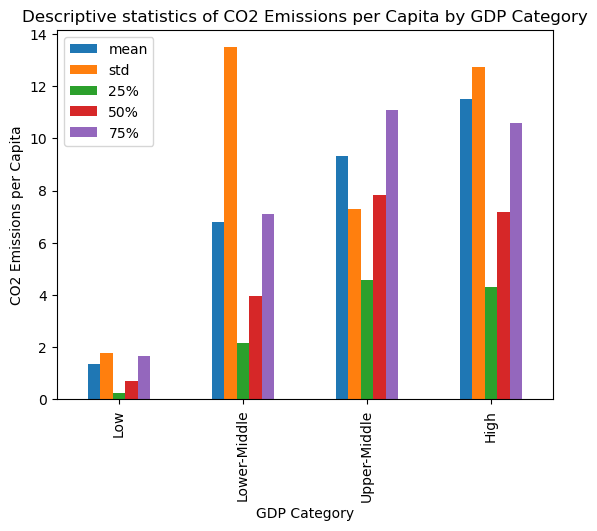

In [55]:
# Plot 1: Customized bar chart or line chart of aggregated subgroups
df_merged_descriptive['CO2 emissions per capita'].drop(columns=['count', 'max', 'min']).plot(kind='bar')
plt.title("Descriptive statistics of CO2 Emissions per Capita by GDP Category")
plt.xlabel("GDP Category")
plt.ylabel("CO2 Emissions per Capita")
plt.show()

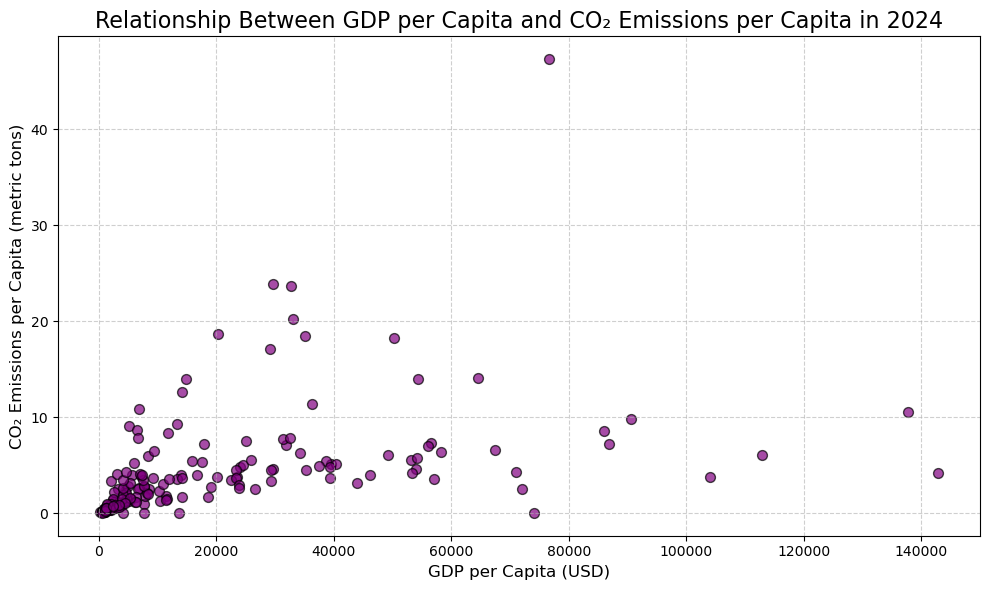

In [56]:
# Plot 2: Customized scatter plot of primary policy variables
df_2024 = df_merged[df_merged['Year'] == 2024]

plt.figure(figsize=(10,6))

plt.scatter(
    df_2024['GDP per capita'],
    df_2024['CO2 emissions per capita'],
    s=50,
    color='purple',
    edgecolors='black',
    alpha=0.7,
    marker='o'
)

plt.title('Relationship Between GDP per Capita and CO₂ Emissions per Capita in 2024', fontsize=16)
plt.xlabel('GDP per Capita (USD)', fontsize=12)
plt.ylabel('CO₂ Emissions per Capita (metric tons)', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

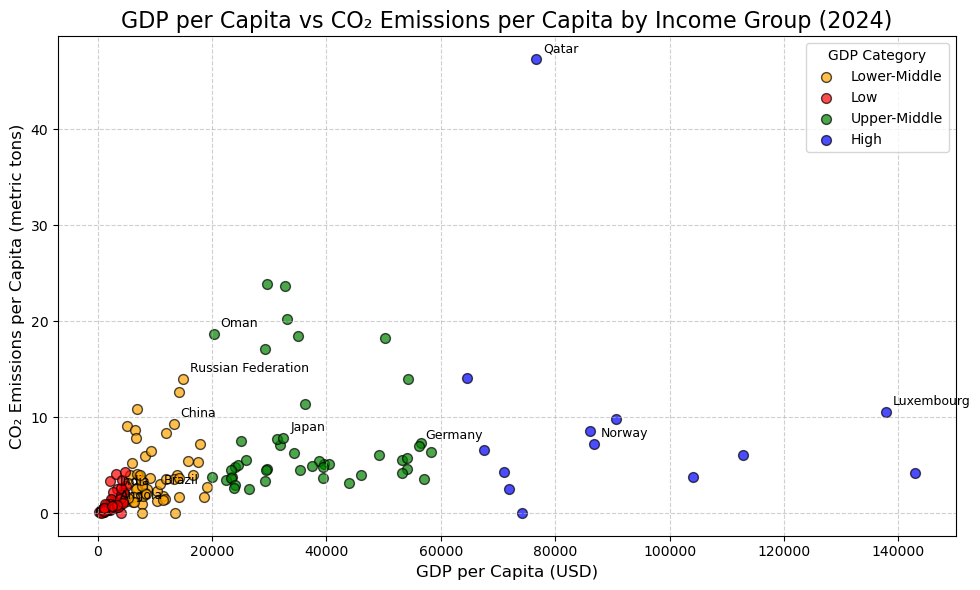

In [57]:
plt.figure(figsize=(10,6))

colors = {
    'Low': 'red',
    'Lower-Middle': 'orange',
    'Upper-Middle': 'green',
    'High': 'blue'
}

for category in df_2024['GDP Category'].unique():
    subset = df_2024[df_2024['GDP Category'] == category]

    plt.scatter(
        subset['GDP per capita'],
        subset['CO2 emissions per capita'],
        s=50,
        color=colors[category],
        edgecolors='black',
        alpha=0.7,
        label=category
    )

plt.title('GDP per Capita vs CO₂ Emissions per Capita by Income Group (2024)', fontsize=16)
plt.xlabel('GDP per Capita (USD)', fontsize=12)
plt.ylabel('CO₂ Emissions per Capita (metric tons)', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='GDP Category')

countries_to_label = [
    'Angola',
    'United States',
    'China',
    'India',
    'Japan',
    'Germany',
    'Brazil',
    'Norway',
    'Qatar',
    'Luxembourg',
    'Russian Federation',
    'Oman'
]

for country in countries_to_label:
    row = df_2024[df_2024['Country'] == country]

    if not row.empty:
        plt.annotate(
            country,
            (
                row['GDP per capita'].iloc[0],
                row['CO2 emissions per capita'].iloc[0]
            ),
            xytext=(5,5),
            textcoords='offset points',
            fontsize=9
        )

plt.tight_layout()
plt.show()

In [58]:
print(df_merged['Country'].unique())
print(df_merged[df_merged['Country'].str.contains('United', case=False, na=False)]['Country'].unique())

['Afghanistan' 'Albania' 'Algeria' 'Angola' 'Antigua and Barbuda'
 'Argentina' 'Armenia' 'Aruba' 'Australia' 'Austria' 'Azerbaijan'
 'Bahamas, The' 'Bahrain' 'Bangladesh' 'Barbados' 'Belarus' 'Belgium'
 'Belize' 'Benin' 'Bermuda' 'Bhutan' 'Bolivia' 'Bosnia and Herzegovina'
 'Botswana' 'Brazil' 'Brunei Darussalam' 'Bulgaria' 'Burkina Faso'
 'Burundi' 'Cabo Verde' 'Cambodia' 'Cameroon' 'Canada' 'Cayman Islands'
 'Chad' 'Chile' 'China' 'Colombia' 'Comoros' 'Congo, Dem. Rep.'
 'Congo, Rep.' 'Costa Rica' "Cote d'Ivoire" 'Croatia' 'Cuba' 'Cyprus'
 'Czechia' 'Denmark' 'Djibouti' 'Dominica' 'Dominican Republic' 'Ecuador'
 'Egypt, Arab Rep.' 'El Salvador' 'Equatorial Guinea' 'Eritrea' 'Estonia'
 'Eswatini' 'Ethiopia' 'Faroe Islands' 'Fiji' 'Finland' 'France'
 'French Polynesia' 'Gabon' 'Gambia, The' 'Georgia' 'Germany' 'Ghana'
 'Greece' 'Greenland' 'Grenada' 'Guam' 'Guatemala' 'Guinea'
 'Guinea-Bissau' 'Guyana' 'Haiti' 'Honduras' 'Hong Kong SAR, China'
 'Hungary' 'Iceland' 'India' 'Indonesia' '

Just noticed that for some reason the US doesnt appear!!! I lost it at some point

In [59]:
import statsmodels.api as sm


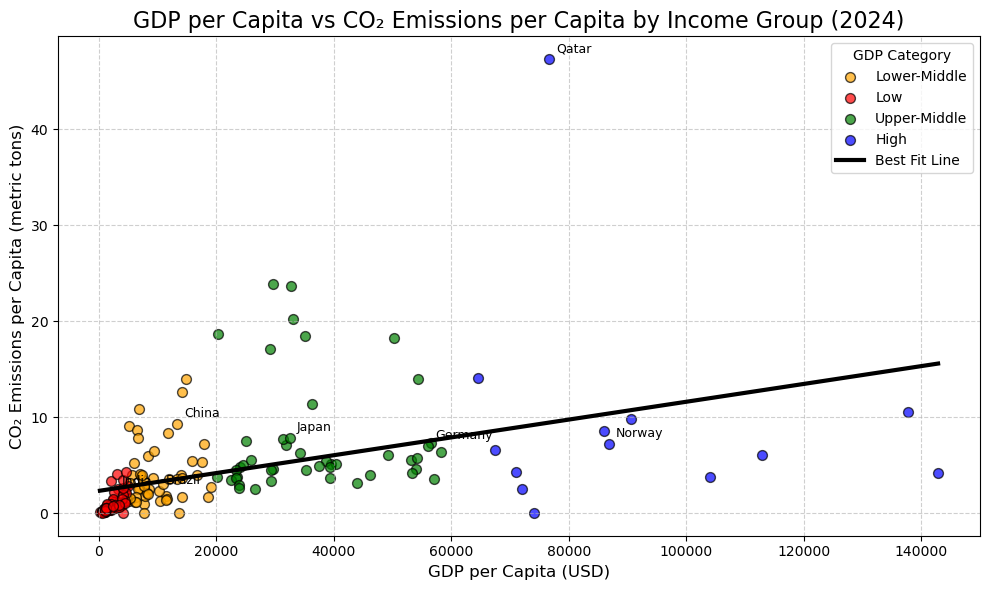

                               OLS Regression Results                               
Dep. Variable:     CO2 emissions per capita   R-squared:                       0.192
Model:                                  OLS   Adj. R-squared:                  0.187
Method:                       Least Squares   F-statistic:                     41.95
Date:                      Thu, 04 Jun 2026   Prob (F-statistic):           8.95e-10
Time:                              23:30:06   Log-Likelihood:                -540.46
No. Observations:                       179   AIC:                             1085.
Df Residuals:                           177   BIC:                             1091.
Df Model:                                 1                                         
Covariance Type:                  nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------

In [60]:
# Fit a simple linear regression and overlay the line of best fit
plt

X = sm.add_constant(df_2024['GDP per capita'])
y = df_2024['CO2 emissions per capita']

model = sm.OLS(y, X).fit()

plt.figure(figsize=(10,6))

colors = {
    'Low': 'red',
    'Lower-Middle': 'orange',
    'Upper-Middle': 'green',
    'High': 'blue'
}

for category in df_2024['GDP Category'].unique():
    subset = df_2024[df_2024['GDP Category'] == category]

    plt.scatter(
        subset['GDP per capita'],
        subset['CO2 emissions per capita'],
        s=50,
        color=colors[category],
        edgecolors='black',
        alpha=0.7,
        label=category
    )

countries_to_label = [
    'China',
    'India',
    'Japan',
    'Germany',
    'Norway',
    'Qatar',
    'Brazil'
]

for country in countries_to_label:
    row = df_2024[df_2024['Country'] == country]

    if not row.empty:
        plt.annotate(
            country,
            (
                row['GDP per capita'].iloc[0],
                row['CO2 emissions per capita'].iloc[0]
            ),
            xytext=(5,5),
            textcoords='offset points',
            fontsize=9
        )

df_line = df_2024.sort_values('GDP per capita')

plt.plot(
    df_line['GDP per capita'],
    model.predict(sm.add_constant(df_line['GDP per capita'])),
    color='black',
    linewidth=3,
    label='Best Fit Line'
)

plt.title('GDP per Capita vs CO₂ Emissions per Capita by Income Group (2024)', fontsize=16)
plt.xlabel('GDP per Capita (USD)', fontsize=12)
plt.ylabel('CO₂ Emissions per Capita (metric tons)', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='GDP Category')

plt.tight_layout()
plt.show()

print(model.summary())


We see a positive relationship between GDP per capita and co2 emmissions per capita. However, there are some outliers, especially as we move from lower to higher income groups (lower income countries are pretty concentrated). The regression indicates a statistically significant relationship. The coefficient between both suggeststs that +1000USD associates with 0.093 metric tons of co2 per capita. The r2 value shows us that GDP per capita explains 19.2% of the variation of emissions per capita: so it is definitely not the only factor at play

### **Submission Checklist**

- **Out-of-the-Box Execution**
  - Select `Kernel -> Restart & Run All` to verify all cells run without error.
- **Reproducibility & Paths**
  - Verify that both the notebook and the dataset are saved and committed in Git.
  - Ensure all files are loaded using relative paths.
- **Visual Elements & Design**
  - Ensure all plots are fully customized, clearly labeled, and have titles.